# Spacing Statistics

## 1. Importing / Installing Packages

In [33]:
from __future__ import annotations

import os
from pathlib import Path

import pandas as pd
pd.set_option("display.max_columns", None) # Show all columns when printing DataFrames

import numpy as np
import math

import datetime

from matplotlib import pyplot as plt
# Ensures that plots are displayed inline in Jupyter notebooks
%matplotlib inline
%config InlineBackend.figure_format = 'svg' # Configuring inline backend to use SVG format for figures

from dataclasses import dataclass
from enum import Enum, auto

from typing import Dict, Tuple, List, Union, Optional, ClassVar, Any, Literal, Iterable

from src.utils import DatabricksOdbcConnector, reorder_columns, compute_bg_rcat, read_excel_with_mapper, standardize_column_names, read_csv_with_mapper, add_producing_months, calculate_cumulative_volumes_by_period
from src.well_data import WellDataLoader, GeoSurveyProcessor, DirectionalBenchNeighbors, WellSpacingCalculator, FloatingSectionWPS, BoxSpec, CorridorSpec

## 2. Import Data

### 2.1 Reading Header Data From File

In [2]:
df_header_raw = read_excel_with_mapper(
    path=r"C:\Users\ApoorvaSaxena\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\01. EF - 74 Ranch\Header Data\header_ranch_74_EF.xlsx",
    sheet_name="header",
    col_map={"API14": "uwi", "API12": "uwi12", "API10": "uwi10", "WellName":"well_name",
             "SpudDate":"spud_dt", "CompletionDate": "comp_dt",	"FirstProdDate":"first_prod_dt",
             "LastProdDate":"last_prod_dt", "ENVInterval":"bench"
             },
    dtype_map={"uwi": str, "uwi12": str, "uwi10": str, "well_name": str},
    parse_dates=["SpudDate", "CompletionDate", "FirstProdDate", "LastProdDate"] # Parsing date columns during import because it’s handled inside pd.read_excel before we rename.
)

### 2.2 Standardizing Columns

In [3]:
df_header_standardize = standardize_column_names(df_header_raw)

### 2.3 Reading Directional Survey From File

In [4]:
df_directional_survey_raw = read_csv_with_mapper(
    path=r"C:\Users\ApoorvaSaxena\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\01. EF - 74 Ranch\Directional Data\ds_wellbore_trajectories_ranch74_EF.CSV",
    col_map={"API Number":"uwi12", "Measured Depth":"md", "Inclination":"inclination", "Azimuth":"azimuth", 
             "True Vertical Depth":"tvd", "N_S":"N/S", "E_W":"E/W", "Latitude":"latitude", "Longitude":"longitude"},
    dtype_map={"uwi12": str},
    usecols=['API Number', 'Measured Depth', 'Inclination','Azimuth', 'True Vertical Depth', 'N_S', 'E_W', 'Latitude','Longitude']
)

### 2.4 Merge to add 'uwi' to directional survey data and reorder columns

In [5]:
df_directional_uwi = df_directional_survey_raw.merge(df_header_standardize[["uwi12","uwi"]], how='left', on='uwi12', copy=True).reset_index(drop=True)

df_directional_uwi = reorder_columns(df_directional_uwi, columns_to_move=["uwi"], reference_column="uwi12").copy()

## 3. Computing Reserve Category

### 3.1 Bg_Rscat

In [6]:
df_header_standardize["bg_rcat"] = compute_bg_rcat(df=df_header_standardize,
                col_map = {
        "status": "env_well_status",
        "last_prod": "last_prod_dt",
        "spud": "spud_dt",
        "comp": "comp_dt"
    })

### 3.2 Removing/Deleting rows from header data where rcat is blank

In [7]:
df_header_standardize = df_header_standardize[df_header_standardize["bg_rcat"] != ""].reset_index(drop=True).copy()

## 4. UTM Coordinates

### 4.1 Computing UTM Coordinates

In [8]:
# Initialize the GeoSurveyProcessor with the log directory
geo = GeoSurveyProcessor(log_dir=r"C:\Users\ApoorvaSaxena\OneDrive - Bandera Group\Desktop\Project AP\02.Python\well-spacing-analyzer\notebooks\logs")

[GeoLogger] INFO (12-09 09:21 PM): GeoSurveyProcessor initialized. (Line: 472) [well_data_manager.py]



In [9]:
df_utm = geo.compute_utm_coordinates(df=df_directional_uwi)

[GeoLogger] INFO (12-09 09:21 PM): ✅ Using lat/lon from input DataFrame. (Line: 648) [well_data_manager.py]

[GeoLogger] INFO (12-09 09:21 PM): ✅ UTM coordinate computation complete in 0.32 sec. (Line: 703) [well_data_manager.py]



### 4.2 Filtering to get only the lateral sections after the heel point

In [10]:
df_utm_lateral = geo.filter_after_heel_point(df=df_utm)

### 4.3 Calculate midpoints for lateral wells

In [11]:
df_midpoints_lateral = geo.get_heel_toe_midpoints_latlon(df=df_utm_lateral)

In [47]:
df_midpoints_lateral

,uwi,heel_lat,heel_lon,toe_lat,toe_lon,mid_Lat,mid_Lon
0,42013342730000,28.726665,-98.454854,28.715778,-98.449500,28.721221,-98.452177
1,42013342790000,28.725676,-98.449530,28.716139,-98.440671,28.720907,-98.445101
2,42013342820000,28.719554,-98.455705,28.708547,-98.450302,28.714051,-98.453004
3,42013342840000,28.728828,-98.447063,28.719261,-98.438123,28.724044,-98.442593
4,42013342850000,28.733020,-98.440268,28.724081,-98.431656,28.728550,-98.435962
...,...,...,...,...,...,...,...
1784,42311375320000,28.626207,-98.365902,28.643165,-98.381824,28.634686,-98.373863
1785,42311375330000,28.626122,-98.367622,28.643175,-98.383865,28.634649,-98.375743
1786,42311375760000,28.576648,-98.400503,28.586595,-98.412629,28.581622,-98.406566
1787,42311375770000,28.577858,-98.400678,28.575975,-98.402819,28.576916,-98.401748


## 5. Spacing

### 5.1 Filtering header data to include certain RSV category and missing uwi in Directional Survey from header data

In [12]:
missing_uwi = set(df_header_standardize['uwi']) - set(df_directional_uwi['uwi'])
print(f"Number of missing UWI12: {len(missing_uwi)}")
# list(missing_uwi)

Number of missing UWI12: 226


In [13]:
df_header_filter_for_spacing = df_header_standardize[~(df_header_standardize["uwi"].isin(missing_uwi)) & 
          (df_header_standardize["bg_rcat"].isin(["1PDP", "1PDSI", "1WOP"]))].reset_index(drop=True).copy()

In [14]:
list(set(df_header_filter_for_spacing['uwi12']) - set(df_utm_lateral[df_utm_lateral["uwi12"].isin(df_header_filter_for_spacing["uwi12"].unique())]["uwi12"]))

[]

### 5.2 Calculating Spacing

In [15]:
# Create an instance of WellSpacingCalculator with the filtered trajectories
spacing_stats_ik = WellSpacingCalculator(trajectories=df_utm_lateral[df_utm_lateral["uwi12"].isin(df_header_filter_for_spacing["uwi12"].unique())])

In [16]:
# Calculate spacing statistics with specified parameters and save the results in parquet files
# spacing_stats_ik._calculate_spacing_statistics(
#     batch_size=200_000,
#     max_distance_miles=4.0,
#     save_batches_dir=r"C:\Users\ApoorvaSaxena\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\01. EF - 74 Ranch\SpacingStats",
#     max_crossline_ft=5_280
# )

### 5.3 Read Calculated and Saved Spacing Results from Parquet Files

In [17]:
df_spacing_ik = spacing_stats_ik._load_saved_batches(
    batch_folder=r"C:\Users\ApoorvaSaxena\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\01. EF - 74 Ranch\SpacingStats"
)

🔍 Found 3 batch files. Loading and combining...
✅ Loaded 358,079 rows from all batches.


### 5.4 Filtering out rows where 'reject_reason' is empty

In [18]:
# Filter out rows where 'reject_reason' is not empty
df_spacing_ik_filt = df_spacing_ik[df_spacing_ik["reject_reason"]==""].reset_index(drop=True).copy()

### 5.5 Joining bench with spacing ik filtered dataframe

In [19]:
bench_map = df_header_filter_for_spacing.set_index("uwi")["bench"]

df_spacing_ik_filt["bench_i"] = df_spacing_ik_filt["well_i"].map(bench_map)
df_spacing_ik_filt["bench_k"] = df_spacing_ik_filt["well_k"].map(bench_map)

df_spacing_ik_filt = reorder_columns(df=df_spacing_ik_filt, columns_to_move=['bench_i', 'bench_k'], reference_column='well_k')
df_spacing_ik_filt = reorder_columns(df=df_spacing_ik_filt, 
                                        columns_to_move=['direction_to_k_from_i_axis','overlap_pct_i', 'overlap_pct_k','overlap_len_common_ft', 'LL_i', 'LL_k'], 
                                        reference_column='3D_dist')

In [20]:
df_spacing_ik_filt

,well_i,well_k,bench_i,bench_k,horizontal_dist,horizontal_dist_median,vertical_dist,3D_dist,direction_to_k_from_i_axis,overlap_pct_i,overlap_pct_k,overlap_len_common_ft,LL_i,LL_k,drill_direction_i,drill_direction_k,n_samples,dy_p5,angle_deg,pair_alignment,min_distance_ft,mean_windowed_ft,reject_reason,direction_axis,direction_axis_confidence,direction_axis_distribution,axis_forced,proj_coverage_i_pct,contact_threshold_ft,contact_len_i_ft,contact_pct_i,contact_len_i_interior_ft,contact_pct_i_interior,contact_len_i_ft_T300,contact_pct_i_T300,contact_len_i_interior_ft_T300,contact_pct_i_interior_T300,horizontal_crossline_mean_ft,hz_effective,hz_basis,3D_dist_effective
0,42013342730000,42013342790000,LOWER EAGLE FORD,LOWER EAGLE FORD,1902.879787,1902.909447,34.825,1903.198430,E,0.765680,0.737520,3305.171458,4316.650152,4481.466637,NS,NS,34.0,1463.219090,15.444912,parallel_like,NaN,NaN,,EW,1.000000,"E:1.00,W:0.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1902.879787,1902.879787,crossline_mean,1903.198430
1,42013342730000,42013342820000,LOWER EAGLE FORD,LOWER EAGLE FORD,1321.768703,1322.414690,48.490,1322.657848,W,0.475751,0.470422,2053.649941,4316.650152,4365.544397,NS,NS,21.0,1284.317629,0.804993,parallel_like,NaN,NaN,,EW,1.000000,"E:0.00,W:1.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1321.768703,1321.768703,crossline_mean,1322.657848
2,42013342730000,42013342840000,LOWER EAGLE FORD,LOWER EAGLE FORD,3225.871104,3235.786645,46.320,3226.203640,E,0.935862,0.894966,4039.788356,4316.650152,4513.901538,NS,NS,41.0,2657.910100,16.677526,parallel_like,NaN,NaN,,EW,1.000000,"E:1.00,W:0.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3225.871104,3225.871104,crossline_mean,3226.203640
3,42013342730000,42013342850000,LOWER EAGLE FORD,LOWER EAGLE FORD,5823.335405,5833.008636,53.540,5823.581524,E,0.888338,0.899004,3834.646326,4316.650152,4265.439996,NS,NS,39.0,5314.799568,16.957152,parallel_like,NaN,NaN,,EW,1.000000,"E:1.00,W:0.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5823.335405,5823.335405,crossline_mean,5823.581524
4,42013342730000,42013342900000,LOWER EAGLE FORD,LOWER EAGLE FORD,4663.942570,4653.413885,43.075,4664.141481,E,0.841736,0.837354,3633.478966,4316.650152,4339.236621,NS,NS,37.0,4171.712370,16.516507,parallel_like,NaN,NaN,,EW,1.000000,"E:1.00,W:0.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4663.942570,4663.942570,crossline_mean,4664.141481
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60066,42311375330000,42311369620000,LOWER EAGLE FORD,LOWER EAGLE FORD,3044.582375,3045.925834,104.480,3046.374552,W,0.653720,0.535908,5297.531916,8103.670013,9885.157593,NS,NS,53.0,3025.820306,0.530898,parallel_like,NaN,NaN,,EW,0.989199,"E:0.01,W:0.99",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3044.582375,3044.582375,crossline_mean,3046.374552
60067,42311375330000,42311369630000,LOWER EAGLE FORD,LOWER EAGLE FORD,3444.303719,3443.729603,54.170,3444.729670,W,0.646866,0.531566,5241.985413,8103.670013,9861.405063,NS,NS,53.0,3420.816866,0.656170,parallel_like,NaN,NaN,,EW,1.000000,"E:0.00,W:1.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3444.303719,3444.303719,crossline_mean,3444.729670
60068,42311375330000,42311375300000,LOWER EAGLE FORD,LOWER EAGLE FORD,1489.815193,1496.372945,52.230,1490.730453,E,0.882829,0.883974,7154.152327,8103.670013,8093.170079,NS,NS,72.0,1449.060542,0.288849,parallel_like,NaN,NaN,,EW,1.000000,"E:1.00,W:0.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1489.815193,1489.815193,crossline_mean,1490.730453
60069,42311375330000,42311375310000,LOWER EAGLE FORD,LOWER EAGLE FORD,971.849701,971.887357,32.185,972.382494,E,0.901060,0.921935,7301.895458,8103.670013,7920.180512,NS,NS,73.0,940.034985,0.131446,parallel_like,NaN,NaN,,EW,1.000000,"E:1.00,W:0.00",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,971.849701,971.849701,crossline_mean,972.382494


## 6. One-Lines

### 6.1 Running oneline

In [21]:
nb = DirectionalBenchNeighbors()

one_line_summary = nb.summarize(
    spacing_df=df_spacing_ik_filt, 
    header_df=df_header_filter_for_spacing,
    cutoff_ft=1_320.0,
    vertical_cutoff_ft=200.0,         # global default if per-well vertical is NaN/missing
    axis_mode="any",
    overlap_pct_k_min=0.40,           # global default if per-well overlap is NaN/missing
)

In [22]:
df_header_filter_for_spacing

,uwi,uwi12,uwi10,well_name,country,state_province,county,lease,lease_name,env_operator,env_ticker,env_well_status,trajectory,formation,spud_dt,comp_dt,first_prod_dt,last_prod_dt,bg_rcat,env_peer_group,env_company_type,env_stock_exchange,state_well_type,env_well_type,env_producing_method,env_region,env_basin,env_play,env_sub_play,bench,env_interval_source,latitude,longitude,latitude_bh,longitude_bh,tvd_ft,md_ft,district,field,block,abstract,platform,section,township,range,section_township_range,unit_name,well_number,plug_date,avg_fluid_per_stage_bbl,frac_rig_onsite_date,frac_rig_release_date,avg_proppant_per_cluster_lbs,avg_proppant_per_shot_lbs,avg_proppant_per_stage_lbs,stimulated_stages,total_clusters,vintage,first_prod_quarter,first_prod_month,completion_time_days,permit_to_spud_days,spud_to_rig_release_days,spud_to_completion_days,spud_to_sales_days,soak_time_days,number_of_strings,upper_perf_ft,lower_perf_ft,perf_interval_ft,lateral_length_ft,frac_stages,average_stage_spacing_ft,proppant_loading_lbs_per_gal,proppant_intensity_lbs_per_ft,proppant_lbs,total_water_pumped_gal,water_intensity_gal_per_ft,total_fluid_pumped_bbl,fluid_intensity_bbl_per_ft,bottom_hole_temp_degf,casing_pressure_psi,flowing_tubing_pressure_psi,shut_in_pressure_psi,oil_gravity_api,total_producing_months,last_month_liquids_production_bbl,last_month_gas_production_mcf,last_month_water_production_bbl,top_of_zone_ft,bottom_of_zone_ft,density_porosity_pct,effective_porosity_pct,clay_volume_pct,non_clay_volume_pct,water_saturation_pct,total_organic_carbon_wtpct,gas_initial_rate,gas_b_factor
0,42013343750000,420133437500,4201334375,GSH UNIT 10H,US,TX,ATASCOSA,15642,GSH UNIT,CRESCENT ENERGY COMPANY,CRGY,PRODUCING,HORIZONTAL,EAGLE FORD,2011-10-09 00:00:00,2012-01-03,2012-01-01,2025-09-01,1PDP,MID CAP,PUBLIC,NYSE,OIL_WELL,OIL,PUMPING,GULF COAST,WESTERN GULF,EAGLE FORD,EAGLE FORD WEST VOLATILE OIL,LOWER EAGLE FORD,ENV INTERPRETED,28.677998,-98.404239,28.668345,-98.395768,10436.0,14834.0,1,EAGLEVILLE,NaN,963.0,NaN,23.0,NaN,NaN,NaN,GSH UNIT,10H,NaT,133427.0,NaN,NaN,NaN,NaN,6299342.0,NaN,NaN,2012.0,2012-Q1,2012 / 01,1.0,136.0,16.0,86.0,99.0,32.0,2.0,10510.0,14803.0,4293.0,4271.0,18.0,237.0,1.12,1467.0,6299342.0,5603934.0,1305.0,133427.0,31.0,NaN,NaN,2350.0,NaN,41.0,165.0,298.0,0.0,77.0,10173.0,10290.0,0.091,0.071,0.17,0.70,0.29,3.99,1.36,0.95
1,42013344800000,420133448000,4201334480,MIDDLE MCCOWEN 8H,US,TX,ATASCOSA,15638,MIDDLE MCCOWEN,CONOCOPHILLIPS,COP,PRODUCING,HORIZONTAL,EAGLE FORD,2012-05-22 00:00:00,2012-07-02,2012-07-01,2025-09-01,1PDP,LARGE CAP,PUBLIC,NYSE,OIL_WELL,OIL,PUMPING,GULF COAST,WESTERN GULF,EAGLE FORD,EAGLE FORD EAST VOLATILE OIL,LOWER EAGLE FORD,ENV INTERPRETED,28.652433,-98.321220,28.665132,-98.333289,10891.0,16860.0,1,EAGLEVILLE,NaN,64.0,NaN,153.0,NaN,NaN,NaN,MIDDLE MCCOWEN,8H,NaT,8068.0,NaN,NaN,NaN,NaN,256083.0,NaN,NaN,2012.0,2012-Q3,2012 / 07,NaN,76.0,26.0,41.0,55.0,10.0,2.0,11199.0,16684.0,5485.0,5623.0,17.0,331.0,1.49,797.0,4371121.0,2940394.0,536.0,70009.0,13.0,NaN,2000.0,NaN,NaN,42.0,159.0,205.0,66.0,8.0,10721.0,10843.0,0.105,0.088,0.15,0.74,0.26,4.60,1.02,0.85
2,42013344820000,420133448200,4201334482,MIDDLE MCCOWEN 10H,US,TX,ATASCOSA,15638,MIDDLE MCCOWEN,CONOCOPHILLIPS,COP,PRODUCING,HORIZONTAL,EAGLE FORD,2012-06-11 00:00:00,2012-08-30,2012-08-01,2025-09-01,1PDP,LARGE CAP,PUBLIC,NYSE,OIL_WELL,OIL,PUMPING,GULF COAST,WESTERN GULF,EAGLE FORD,EAGLE FORD EAST VOLATILE OIL,LOWER EAGLE FORD,ENV INTERPRETED,28.647486,-98.325239,28.631683,-98.310760,11119.0,18111.0,1,EAGLEVILLE,NaN,64.0,NaN,153.0,NaN,NaN,NaN,MIDDLE MCCOWEN,10H,NaT,54776.0,NaN,NaN,NaN,NaN,3642250.0,NaN,NaN,2012.0,2012-Q3,2012 / 08,NaN,95.0,21.0,80.0,66.0,18.0,2.0,11419.0,17991.0,6572.0,6755.0,19.0,356.0,1.58,554.0,3642250.0,2300592.0,350.0,54776.0,8.0,NaN,2200.0,2803.0,NaN,43.0,158.0,349.0,138.0,12.0,10934.0,11003.0,0.109,0.091,0.14,0.74,0.24,4.75,1.20,0.85
3,42013344880000,420133448800,4201334488,ET 1H,US,TX,ATASCOSA,16135,ET,MURPHY OIL,MUR,PRODUCING,HORIZONTAL,EAGLE FORD,2012-05

In [23]:
one_line_summary

,well_i,uwi_same_1,hz_ft_to_same_1,vt_ft_to_same_1,3d_ft_to_same_1,uwi_same_2,hz_ft_to_same_2,vt_ft_to_same_2,3d_ft_to_same_2,uwi_near_1,hz_ft_to_near_1,vt_ft_to_near_1,3d_ft_to_near_1,uwi_near_2,hz_ft_to_near_2,vt_ft_to_near_2,3d_ft_to_near_2,override_applied,eff_cutoff_ft,eff_vertical_cutoff_ft,eff_overlap_pct_k_min
0,42013342730000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1320.0,200.0,0.4
1,42013342790000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1320.0,200.0,0.4
2,42013342820000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1320.0,200.0,0.4
3,42013342840000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1320.0,200.0,0.4
4,42013342850000,42013342900000,1277.717563,10.465,1277.760418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1320.0,200.0,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1701,42311375150000,42311375130000,354.584434,77.190,362.888987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1320.0,200.0,0.4
1702,42311375300000,42311375310000,514.571210,20.045,514.961486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1320.0,200.0,0.4
1703,42311375310000,42311375320000,496.166296,17.380,496.470601,42311375300000,514.569867,20.045,514.960144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1320.0,200.0,0.4
1704,42311375320000,42311375330000,477.870620,14.805,478.099903,42311375310000,496.173642,17.380,496.477943,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,1320.0,200.0,0.4


In [28]:
# spacing_stats_ik.debug_pair_spacing(uwi_i="42013344920000", uwi_k="42311373690000")

## 7. WPS

### 7.1 Calculating WPS

In [24]:
box = BoxSpec(half_width_ft=5280.0 / 2,  # 2640 ft (1 mile wide)
              half_height_ft=5280.0 / 2)  # 5280 ft (2 miles tall)

corr = CorridorSpec(half_width_ft=2640.0, extra_along_ft=0)

wells_df = FloatingSectionWPS.ds_to_lateral_endpoints(df_utm_lateral)

wps = FloatingSectionWPS(
    wells_df,
    # box=BoxSpec(2640, 2640),
    box=box,
    min_inside_ft=1000.0,
    exclude_self=False,
    corridor=corr,
)


df_wps_summary = wps.summarize_per_well()

In [25]:
df_wps_summary

,well_i,wps_cardinal,wps_iframe,wps_corridor,anisotropy_ratio,anisotropy_delta,azimuth_deg,mid_x,mid_y
0,42013342730000,5,4,4,0.800000,-1.0,156.299129,1.815948e+06,1.042396e+07
1,42013342790000,4,3,3,0.750000,-1.0,140.419649,1.818216e+06,1.042386e+07
2,42013342820000,3,3,3,1.000000,0.0,156.338964,1.815695e+06,1.042135e+07
3,42013342840000,4,3,3,0.750000,-1.0,140.254086,1.819014e+06,1.042500e+07
4,42013342850000,5,4,3,0.800000,-1.0,139.388471,1.821131e+06,1.042665e+07
...,...,...,...,...,...,...,...,...,...
1784,42311375320000,6,4,4,0.666667,-2.0,320.062927,1.841206e+06,1.039263e+07
1785,42311375330000,7,5,6,0.714286,-2.0,319.659868,1.840603e+06,1.039261e+07
1786,42311375760000,13,11,11,0.846154,-2.0,312.618853,1.830815e+06,1.037329e+07
1787,42311375770000,12,13,3,1.083333,1.0,224.823274,1.832369e+06,1.037159e+07


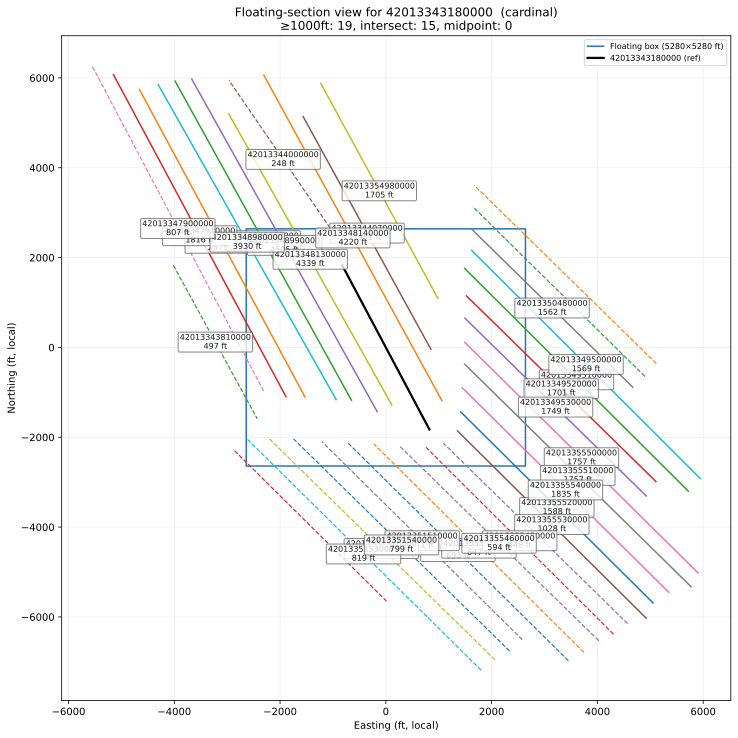

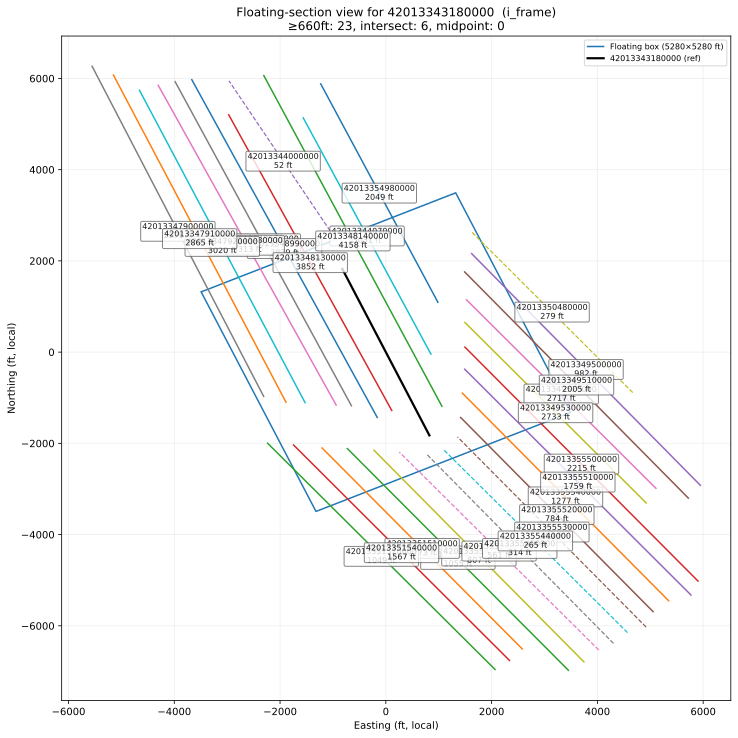

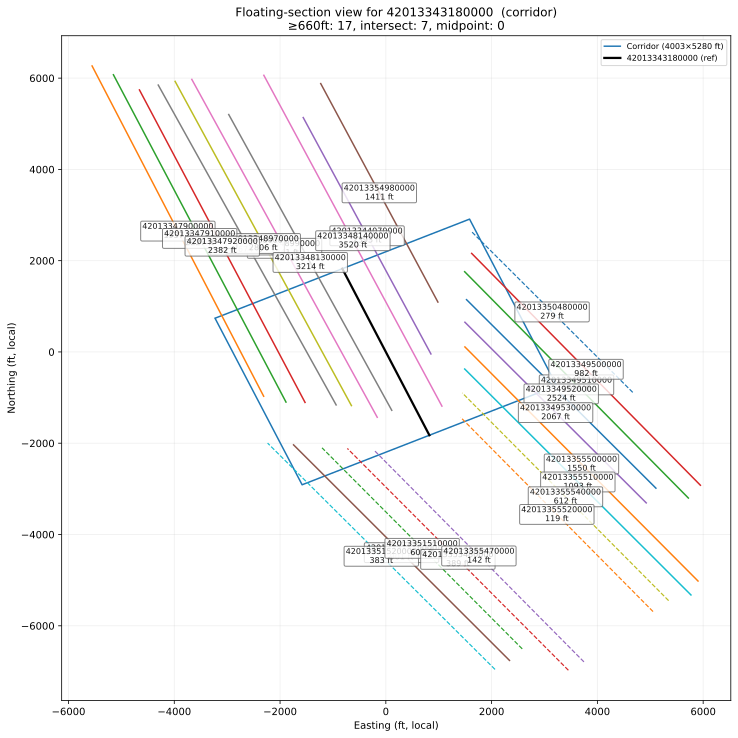

In [26]:
uwi = "42013343180000"
# uwi = "42013356560000"

# Cardinal floating-section view
fig = wps.visualize(uwi, orientation="cardinal", figsize=(12,12))

# I-frame view (box aligned to reference lateral)
fig_if = wps.visualize(uwi, orientation="i_frame", min_len_ft=660, figsize=(12,12))

fig_corr = wps.visualize(uwi, orientation="corridor", min_len_ft=660, figsize=(12,12))

## 8. Production

### 8.1 Reading Production Data from file

In [27]:
df_prod_raw = read_csv_with_mapper(
    path=r"C:\Users\ApoorvaSaxena\OneDrive - Bandera Group\Desktop\Project AP\05. Spacing Study\01. EF - 74 Ranch\Production Data\well_monthly_production_ranch74_EF.CSV",
    col_map={"API/UWI":"uwi", "Monthly Production Date":"prod_date"},
    parse_dates=["Monthly Production Date"],
    dtype_map={"uwi": str}
)

In [28]:
df_prod_standardize = standardize_column_names(df_prod_raw)

### 8.2 Calculating Producing Months

In [29]:
df_prod_standardize = add_producing_months(df=df_prod_standardize, date_col="prod_date", uwi_col="uwi", out_col="producing_months_calc")

In [30]:
# Reorder columns to place 'producing_months_calc' after 'prod_date'
df_prod_standardize = reorder_columns(df=df_prod_standardize, columns_to_move=["producing_months_calc"], reference_column="prod_date")

In [31]:
df_prod_standardize

,uwi,prod_date,producing_months_calc,monthly_oil,monthly_gas,monthly_water,monthly_boe,days,cum_oil,cum_gas,cum_water,avg_oil,avg_gas,avg_water,daily_avg_boe,reservoir,di_landing_zone,well_name,well_number,operator_company_name,production_type,well_status,entity_type,total_proppant,total_fluid,gross_perforated_interval,di_lateral_length,producing_month_number,monthly_oil_per_perforated_ft,monthly_gas_per_perforated_ft,monthly_boe_per_perforated_ft,daily_avg_oil_per_perforated_ft,daily_avg_gas_per_perforated_ft,daily_avg_boe_per_perforated_ft,cum_oil_per_perforated_ft,cum_gas_per_perforated_ft,cum_boe_per_perforated_ft
0,42013342730000,2009-12-01,1,7816.0,0.0,0.0,7816.00,0.0,7816.0,0.0,0.0,252.13,0.00,0.00,260.53,MULTIPLE,Eagle Ford Lower,PEELER RANCH,2H,EOG RESOURCES,OIL,ACTIVE,MULTIPLE,4531000.0,NaN,4051.0,4322.0,1,1.81,0.00,1.81,0.0583,0.0000,0.0603,1.81,0.00,1.81
1,42013342730000,2010-01-01,2,4565.0,5595.0,88.0,5497.50,0.0,12381.0,5595.0,88.0,147.26,180.48,2.84,183.25,MULTIPLE,Eagle Ford Lower,PEELER RANCH,2H,EOG RESOURCES,OIL,ACTIVE,MULTIPLE,4531000.0,NaN,4051.0,4322.0,2,1.06,1.29,1.27,0.0341,0.0418,0.0424,2.86,1.29,3.08
2,42013342730000,2010-02-01,3,756.0,302.0,49.0,806.33,NaN,13137.0,5897.0,137.0,27.00,10.79,1.75,26.88,MULTIPLE,Eagle Ford Lower,PEELER RANCH,2H,EOG RESOURCES,OIL,ACTIVE,MULTIPLE,4531000.0,NaN,4051.0,4322.0,3,0.17,0.07,0.19,0.0062,0.0025,0.0062,3.04,1.36,3.27
3,42013342730000,2010-03-01,4,2024.0,1299.0,45.0,2240.50,NaN,15161.0,7196.0,182.0,65.29,41.90,1.45,74.68,MULTIPLE,Eagle Ford Lower,PEELER RANCH,2H,EOG RESOURCES,OIL,ACTIVE,MULTIPLE,4531000.0,NaN,4051.0,4322.0,4,0.47,0.30,0.52,0.0151,0.0097,0.0173,3.51,1.66,3.79
4,42013342730000,2010-04-01,5,1441.0,1554.0,124.0,1700.00,NaN,16602.0,8750.0,306.0,48.03,51.80,4.13,56.67,MULTIPLE,Eagle Ford Lower,PEELER RANCH,2H,EOG RESOURCES,OIL,ACTIVE,MULTIPLE,4531000.0,NaN,4051.0,4322.0,5,0.33,0.36,0.39,0.0111,0.0120,0.0131,3.84,2.02,4.18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158855,42311375330000,2025-05-01,2,23525.0,17364.0,15184.0,26419.00,NaN,55794.0,37355.0,33321.0,758.87,560.13,489.81,880.63,EAGLE FORD-1,NaN,MORRILL RANCH,59,CONOCOPHILLIPS,OIL,ACTIVE,COM,27097104.0,448986.38,8359.0,8109.0,2,2.90,2.14,3.26,0.0936,0.0691,0.1086,6.88,4.61,7.65
158856,42311375330000,2025-06-01,3,17434.0,13342.0,11569.0,19657.67,NaN,73228.0,50697.0,44890.0,581.13,444.73,385.63,655.26,EAGLE FORD-1,NaN,MORRILL RANCH,59,CONOCOPHILLIPS,OIL,ACTIVE,COM,27097104.0,448986.38,8359.0,8109.0,3,2.15,1.65,2.42,0.0717,0.0548,0.0808,9.03,6.25,10.07
158857,42311375330000,2025-07-01,4,15389.0,13032.0,10260.0,17561.00,NaN,88617.0,63729.0,55150.0,496.42,420.39,330.97,585.37,EAGLE FORD-1,NaN,MORRILL RANCH,59,CONOCOPHILLIPS,OIL,ACTIVE,COM,27097104.0,448986.38,8359.0,8109.0,4,1.90,1.61,2.17,0.0612,0.0518,0.0722,10.93,7.86,12.24
158858,42311375330000,2025-08-01,5,13674.0,11969.0,9110.0,15668.83,NaN,102291.0,75698.0,64260.0,441.10,386.10,293.87,522.29,EAGLE FORD-1,NaN,MORRILL RANCH,59,CONOCOPHILLIPS,OIL,ACTIVE,COM,27097104.0,448986.38,8359.0,8109.0,5,1.69,1.48,1.93,0.0544,0.0476,0.0644,12.61,9.34,14.17


In [34]:
df_uwi_180_365d_cum = calculate_cumulative_volumes_by_period(df_prod_standardize)

In [35]:
df_uwi_180_365d_cum

,uwi,lateral_length_ft,cum_oil_180d,cum_gas_180d,cum_water_180d,cum_oil_365d,cum_gas_365d,cum_water_365d,cum_oil_180d_per_ft,cum_gas_180d_per_ft,cum_water_180d_per_ft,cum_oil_365d_per_ft,cum_gas_365d_per_ft,cum_water_365d_per_ft
0,42013342730000,4322.0,16602.0,8750.0,306.0,19386.0,10769.0,1287.0,3.841277,2.024526,0.070801,4.485423,2.491671,0.297779
1,42013342790000,4487.0,17499.0,14869.0,0.0,23042.0,23059.0,2638.0,3.899933,3.313795,0.000000,5.135280,5.139068,0.587921
2,42013342820000,4368.0,20066.0,43.0,0.0,24198.0,2015.0,979.0,4.593864,0.009844,0.000000,5.539835,0.461310,0.224130
3,42013342840000,4516.0,22146.0,15013.0,0.0,33327.0,23464.0,5519.0,4.903897,3.324402,0.000000,7.379761,5.195748,1.222099
4,42013342850000,4268.0,22960.0,12800.0,12548.0,44372.0,29666.0,31216.0,5.379569,2.999063,2.940019,10.396439,6.950797,7.313964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1633,42311375150000,10360.0,91725.0,209081.0,15180.0,91725.0,209081.0,15180.0,8.853764,20.181564,1.465251,8.853764,20.181564,1.465251
1634,42311375300000,8098.0,99219.0,73016.0,55986.0,110363.0,84653.0,62279.0,12.252285,9.016547,6.913559,13.628427,10.453569,7.690664
1635,42311375310000,7925.0,95775.0,70481.0,68357.0,106275.0,81819.0,76040.0,12.085174,8.893502,8.625489,13.410095,10.324164,9.594953
1636,42311375320000,8012.0,91410.0,67995.0,78352.0,114888.0,95260.0,96021.0,11.409136,8.486645,9.779331,14.339491,11.889666,11.984648


In [41]:
df_cum_merge_wps = df_uwi_180_365d_cum.merge(df_wps_summary[['well_i', 'wps_cardinal', 'wps_iframe', 'wps_corridor']].rename(columns={"well_i": "uwi"}), on='uwi', how='left').drop(columns=["lateral_length_ft"]).reset_index(drop=True)

In [42]:
df_cum_merge_wps.shape

(1638, 16)

In [ ]:
# Final merge with header filter
df_header_filter_for_spacing.merge(df_cum_merge_wps, on='uwi', how='left')

,uwi,uwi12,uwi10,well_name,country,state_province,county,lease,lease_name,env_operator,env_ticker,env_well_status,trajectory,formation,spud_dt,comp_dt,first_prod_dt,last_prod_dt,bg_rcat,env_peer_group,env_company_type,env_stock_exchange,state_well_type,env_well_type,env_producing_method,env_region,env_basin,env_play,env_sub_play,bench,env_interval_source,latitude,longitude,latitude_bh,longitude_bh,tvd_ft,md_ft,district,field,block,abstract,platform,section,township,range,section_township_range,unit_name,well_number,plug_date,avg_fluid_per_stage_bbl,frac_rig_onsite_date,frac_rig_release_date,avg_proppant_per_cluster_lbs,avg_proppant_per_shot_lbs,avg_proppant_per_stage_lbs,stimulated_stages,total_clusters,vintage,first_prod_quarter,first_prod_month,completion_time_days,permit_to_spud_days,spud_to_rig_release_days,spud_to_completion_days,spud_to_sales_days,soak_time_days,number_of_strings,upper_perf_ft,lower_perf_ft,perf_interval_ft,lateral_length_ft,frac_stages,average_stage_spacing_ft,proppant_loading_lbs_per_gal,proppant_intensity_lbs_per_ft,proppant_lbs,total_water_pumped_gal,water_intensity_gal_per_ft,total_fluid_pumped_bbl,fluid_intensity_bbl_per_ft,bottom_hole_temp_degf,casing_pressure_psi,flowing_tubing_pressure_psi,shut_in_pressure_psi,oil_gravity_api,total_producing_months,last_month_liquids_production_bbl,last_month_gas_production_mcf,last_month_water_production_bbl,top_of_zone_ft,bottom_of_zone_ft,density_porosity_pct,effective_porosity_pct,clay_volume_pct,non_clay_volume_pct,water_saturation_pct,total_organic_carbon_wtpct,gas_initial_rate,gas_b_factor,cum_oil_180d,cum_gas_180d,cum_water_180d,cum_oil_365d,cum_gas_365d,cum_water_365d,cum_oil_180d_per_ft,cum_gas_180d_per_ft,cum_water_180d_per_ft,cum_oil_365d_per_ft,cum_gas_365d_per_ft,cum_water_365d_per_ft,wps_cardinal,wps_iframe,wps_corridor
0,42013343750000,420133437500,4201334375,GSH UNIT 10H,US,TX,ATASCOSA,15642,GSH UNIT,CRESCENT ENERGY COMPANY,CRGY,PRODUCING,HORIZONTAL,EAGLE FORD,2011-10-09 00:00:00,2012-01-03,2012-01-01,2025-09-01,1PDP,MID CAP,PUBLIC,NYSE,OIL_WELL,OIL,PUMPING,GULF COAST,WESTERN GULF,EAGLE FORD,EAGLE FORD WEST VOLATILE OIL,LOWER EAGLE FORD,ENV INTERPRETED,28.677998,-98.404239,28.668345,-98.395768,10436.0,14834.0,1,EAGLEVILLE,NaN,963.0,NaN,23.0,NaN,NaN,NaN,GSH UNIT,10H,NaT,133427.0,NaN,NaN,NaN,NaN,6299342.0,NaN,NaN,2012.0,2012-Q1,2012 / 01,1.0,136.0,16.0,86.0,99.0,32.0,2.0,10510.0,14803.0,4293.0,4271.0,18.0,237.0,1.12,1467.0,6299342.0,5603934.0,1305.0,133427.0,31.0,NaN,NaN,2350.0,NaN,41.0,165.0,298.0,0.0,77.0,10173.0,10290.0,0.091,0.071,0.17,0.70,0.29,3.99,1.36,0.95,46461.0,56857.0,15124.0,77223.0,129024.0,24769.0,10.797351,13.213340,3.514757,17.946317,29.984662,5.756217,11.0,9.0,9.0
1,42013344800000,420133448000,4201334480,MIDDLE MCCOWEN 8H,US,TX,ATASCOSA,15638,MIDDLE MCCOWEN,CONOCOPHILLIPS,COP,PRODUCING,HORIZONTAL,EAGLE FORD,2012-05-22 00:00:00,2012-07-02,2012-07-01,2025-09-01,1PDP,LARGE CAP,PUBLIC,NYSE,OIL_WELL,OIL,PUMPING,GULF COAST,WESTERN GULF,EAGLE FORD,EAGLE FORD EAST VOLATILE OIL,LOWER EAGLE FORD,ENV INTERPRETED,28.652433,-98.321220,28.665132,-98.333289,10891.0,16860.0,1,EAGLEVILLE,NaN,64.0,NaN,153.0,NaN,NaN,NaN,MIDDLE MCCOWEN,8H,NaT,8068.0,NaN,NaN,NaN,NaN,256083.0,NaN,NaN,2012.0,2012-Q3,2012 / 07,NaN,76.0,26.0,41.0,55.0,10.0,2.0,11199.0,16684.0,5485.0,5623.0,17.0,331.0,1.49,797.0,4371121.0,2940394.0,536.0,70009.0,13.0,NaN,2000.0,NaN,NaN,42.0,159.0,205.0,66.0,8.0,10721.0,10843.0,0.105,0.088,0.15,0.74,0.26,4.60,1.02,0.85,30998.0,24780.0,17710.0,48568.0,41873.0,23287.0,5.512716,4.406900,3.149564,8.637382,7.446737,4.141384,13.0,10.0,10.0
2,42013344820000,420133448200,4201334482,MIDDLE MCCOWEN 10H,US,TX,ATASCOSA,15638,MIDDLE MCCOWEN,CONOCOPHILLIPS,COP,PRODUCING,HORIZONTAL,EAGLE FORD,2012-06-11 00:00:00,2012-08-30,2012-08-01,2025-09-01,1PDP,LARGE CAP,PUBLIC,NYSE,OIL_WELL,OIL,PUMPING,GULF COAST,WESTERN GULF,EAGLE FORD,EAGLE FORD EAST VOLATILE OIL,LOWER EAGLE FORD,ENV INTERPRETED,28.647486,-98.325239,28.631683,-98.310760,11119.0,18111.0,1,EAGLEVIL